# 1D CNN Model Training - Customer Review Classification

This notebook implements and trains the 1D Convolutional Neural Network (CNN) model for the customer review classification project.

The model uses the shared preprocessed hotel review dataset and classifies each review into one of three classes:

- **0 - Poor**
- **1 - Average**
- **2 - Good**

The same processed training, validation, and test datasets are used across all team models to maintain a fair comparison.

In [3]:
# Libraries used for loading data and handling file paths
import os
import sys
import pickle
import numpy as np

# TensorFlow is used to build and train the deep learning model
import tensorflow as tf

# Set random seeds to make the experiment more reproducible
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("Setup completed successfully.")

TensorFlow version: 2.21.0
Setup completed successfully.


## Load Processed Training Data

The CNN uses the same preprocessed data prepared for all four deep learning models.

During model development, only the **training set** and **validation set** are used. The test set remains untouched until the final evaluation to avoid data leakage and maintain a fair model comparison.

In [4]:
# Path to the shared processed dataset
DATA_PATH = "../../data/processed"

# Load the padded training and validation sequences
X_train = np.load(os.path.join(DATA_PATH, "X_train_pad.npy"))
X_val = np.load(os.path.join(DATA_PATH, "X_val_pad.npy"))

# Load the corresponding class labels
y_train = np.load(os.path.join(DATA_PATH, "y_train.npy"))
y_val = np.load(os.path.join(DATA_PATH, "y_val.npy"))

# Load the shared class weights calculated from the training data
with open(os.path.join(DATA_PATH, "class_weights.pkl"), "rb") as file:
    class_weights = pickle.load(file)

print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Validation data shape:", X_val.shape)
print("Validation labels shape:", y_val.shape)
print("Class weights:", class_weights)

Training data shape: (4895, 200)
Training labels shape: (4895,)
Validation data shape: (1049, 200)
Validation labels shape: (1049,)
Class weights: {np.int64(0): np.float64(1.8776371308016877), np.int64(1): np.float64(1.317985998922994), np.int64(2): np.float64(0.585246293639407)}


## Build the 1D CNN Model

The CNN architecture is defined separately in `cnn_model.py`. This keeps the model structure reusable and separates the model definition from the training process.

The initial CNN configuration follows the common project settings used for fair model comparison.

In [5]:
# Import the CNN architecture defined in cnn_model.py
from cnn_model import build_cnn_model

# Build the CNN using the initial project settings
model = build_cnn_model(
    vocab_size=10000,
    sequence_length=200,
    embedding_dim=128,
    num_filters=64,
    kernel_size=5,
    dropout_rate=0.5,
    num_classes=3,
)

# Build the model for input sequences with a length of 200
model.build(input_shape=(None, 200))

# Display the CNN architecture and parameter counts
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 196, 64)        │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 98, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,321,219 (5.04 MB)

 Trainable params: 1,321,219 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

## Train the Initial CNN Model

The CNN is trained using the shared training set and class weights.

The validation set is used to monitor how well the model generalizes to unseen data during training. The test set is not used at this stage.

For the initial experiment, the model is trained for **10 epochs** with a **batch size of 32**, following the common project settings.

In [6]:
# Initial training settings shared across the project
EPOCHS = 10
BATCH_SIZE = 32

# Train the CNN using the training data and monitor validation performance
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    verbose=1,
)

Epoch 1/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.5575 - loss: 0.9887 - val_accuracy: 0.6654 - val_loss: 0.8245
Epoch 2/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6774 - loss: 0.7642 - val_accuracy: 0.7026 - val_loss: 0.6853
Epoch 3/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7412 - loss: 0.6117 - val_accuracy: 0.7169 - val_loss: 0.6156
Epoch 4/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7796 - loss: 0.5153 - val_accuracy: 0.7235 - val_loss: 0.6113
Epoch 5/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8047 - loss: 0.4491 - val_accuracy: 0.7274 - val_loss: 0.6033
Epoch 6/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8210 - loss: 0.4024 - val_accuracy: 0.7388 - val_loss: 0.6074
Epoch 7/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8306 - loss: 0.3712 - val_accuracy: 0.7417 - val_loss: 0.6283
Epoch 8/10
153/153 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8437 - loss: 0.3350 - val_acc

## Training and Validation Learning Curves

The learning curves are used to compare the CNN's training and validation performance across epochs. This helps identify convergence and possible overfitting.

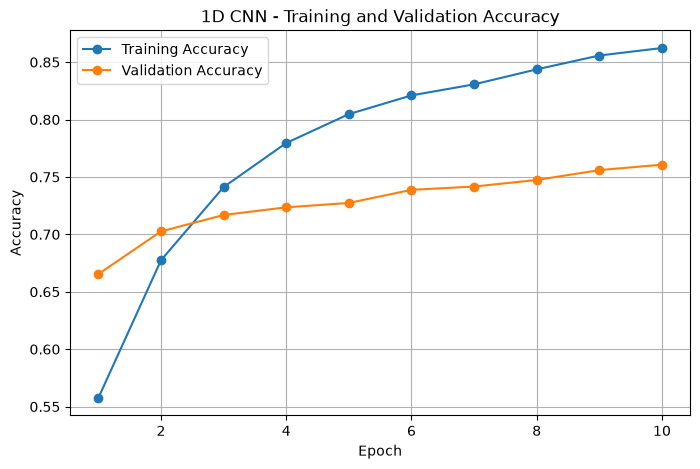

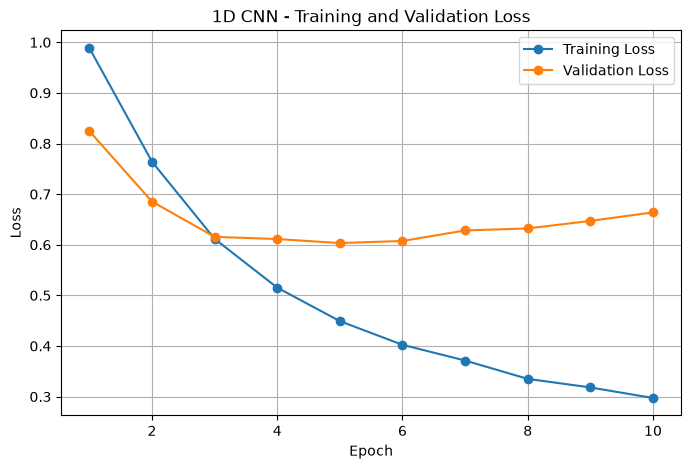

In [7]:
import matplotlib.pyplot as plt

# Get the training results recorded after each epoch
train_accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(train_accuracy) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accuracy, marker="o", label="Training Accuracy")
plt.plot(epochs, val_accuracy, marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("1D CNN - Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, marker="o", label="Training Loss")
plt.plot(epochs, val_loss, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("1D CNN - Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

### Initial Training Analysis

The 1D CNN showed consistent learning across the 10 training epochs. Training accuracy increased from approximately **55.75% to 86.23%**, while validation accuracy improved from approximately **66.54% to 76.07%**.

Training loss continuously decreased from **0.9887 to 0.2973**, showing that the model was learning the training data effectively. Validation loss initially decreased and reached its lowest value of approximately **0.6033 at epoch 5**. After this point, validation loss gradually increased and reached **0.6639 at epoch 10**, while training loss continued to decrease.

This divergence between training and validation loss indicates that the model begins to show signs of **overfitting after approximately epoch 5**. However, validation accuracy continued to improve throughout the 10 epochs. Therefore, the initial experiment provides useful evidence for later evaluation and possible model tuning.